# BSRNN workbook
The aim for this workbook is to start designing the components of the BSRNN from the 'High Fidelity Speech Enhancement BSRNN' paper.

In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torchaudio
import torch.nn as nn
import torch.nn.functional as F
from pathlib import Path
import soundfile as sf
import time
from collections import defaultdict
import math
import yaml

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [38]:
# Load configs
def load_config(model_yaml="bsrnn_baseline.yaml", repo_root=None):
    root = Path(repo_root or Path.cwd())
    while not (root / "CLAUDE.md").exists() and root != root.parent:
        root = root.parent
    cfgs = root / "experiments" / "configs"
    
    model = yaml.safe_load((cfgs / model_yaml).read_text())
    gen   = yaml.safe_load((cfgs / "generator.yaml").read_text())
    
    # Single source of truth: the rate the data was rendered at.
    model["sample_rate"] = gen["sample_rate"]
    return model, root

cfg, ROOT = load_config()
sr     = cfg["sample_rate"]
n_fft  = cfg["model"]["stft"]["n_fft"]
hop    = cfg["model"]["stft"]["hop"]
k      = cfg["model"]["lookahead_frames"]




In [39]:
class TrialDataset(torch.utils.data.Dataset):
    def __init__(self, manifest_csv, data_root, split, chunk_s, sample_rate, seed, random_crop=True):
        self.data_root    = Path(data_root)
        self.split        = split                   
        self.chunk_s      = chunk_s        
        self.sample_rate  = sample_rate
        self.seed         = seed
        self.random_crop  = random_crop
        self.chunk_frames = int(chunk_s * sample_rate)
        self.epoch        = 0                       

        self.manifest_df = pd.read_csv(manifest_csv)

    def __len__(self):
        return len(self.manifest_df)

    def __getitem__(self, idx):
        # there are a couple of things that I need to get:
        # 1. the mixture audio
        # 2. the target speaker audio
        # 3. the enrollment audio

        # Then there are a few things that are not necessary but are useful:
        # 1. the meta data
        # 2. the trial_id
        # 3. the crop absent

        row = self.manifest_df.iloc[idx]
        trial_directory = self.data_root / "rendered" / self.split / row["trial_id"]
        mixture_directory = trial_directory / "mixture.wav"
        number_of_frames = sf.info(str(mixture_directory)).frames

        start_offset = self._crop_offset_start(idx, number_of_frames)
        mixture_audio = self._read_in_wav(mixture_directory, start=start_offset, frames=self.chunk_frames)
        target_audio = self._read_in_wav(trial_directory / "target.wav", start=start_offset, frames=self.chunk_frames)
        enrollment_audio = self._read_in_wav(trial_directory / "enrollment.wav")

        crop_absent = bool(target_audio.abs().max() == 0)
        return {
            "mixture": mixture_audio,
            "target": target_audio,
            "enrollment": enrollment_audio,
            "crop_absent": crop_absent,
            "trial_id": str(row["trial_id"]),
            "meta": {
                "condition":        str(row["condition"]),
                "clip_absent":      bool(row["target_absent"]),
                "sir_db":           float(row["sir_db"]),
                "snr_db":           float(row["snr_db"]),
                "overlap_achieved": float(row["overlap_achieved"]),
                "regime":           str(row["regime"]),
                "same_gender":      float(row["same_gender"]),
            },
        }


    def _read_in_wav(self, path, start=0, frames=-1):
        # Read in a wav file and return a torch tensor of shape (frames,)
        with sf.SoundFile(str(path)) as f:
            assert f.samplerate == self.sample_rate, f"Sample rate mismatch: {f.samplerate} != {self.sample_rate}"
            assert f.channels == 1, f"Channel mismatch: {f.channels} != 1"

            if start > 0:
                f.seek(start)
            
            x = f.read(frames, dtype='float32', always_2d=False)

        return torch.from_numpy(np.ascontiguousarray(x))

    def _crop_offset_start(self, idx, n_frames):
        # This is used to determine the starting point of the crop for the audio. It is important to note that this is only used for the mixture and target audio, not the enrollment audio. The enrollment audio is always read in full.

        max_start = n_frames - self.chunk_frames
        assert max_start >= 0, f"clip {n_frames} shorter than chunk {self.chunk_frames}"

        epoch = self.epoch if self.random_crop else 0
        rng = np.random.default_rng((self.seed, epoch, idx))
        return int(rng.integers(0, max_start + 1))

    def set_epoch(self, epoch):
        # call this at the top of each training epoch to ensure that the random cropping is consistent across all samples in the dataset. This is important for reproducibility and to ensure that the model sees the same data in each epoch.
        self.epoch = epoch


In [40]:
smoke_train_dataset = TrialDataset(
    manifest_csv="./../../data/manifests/smoke_train.csv",
    data_root="./../../data",
    split="smoke_train",
    chunk_s=4.0, # follow CARTSE
    sample_rate=16000,
    seed=42
)

smoke_valid_dataset = TrialDataset(
    manifest_csv="./../../data/manifests/smoke_val.csv",
    data_root="./../../data",
    split="smoke_val",
    chunk_s=4.0, # follow CARTSE
    sample_rate=16000,
    seed=42,
    random_crop=False,
)

smoke_train_loader = torch.utils.data.DataLoader(
    smoke_train_dataset,
    batch_size=12, # Follow CARTSE
    shuffle=True,
    num_workers=4
)

smoke_valid_loader = torch.utils.data.DataLoader(
    smoke_valid_dataset,
    batch_size=12, # Follow CARTSE
    shuffle=False,
    num_workers=4
)

In [41]:
# Example of how to use the dataset and dataloader
for batch in smoke_train_loader:
    mixture = batch["mixture"]
    target = batch["target"]
    enrollment = batch["enrollment"]
    crop_absent = batch["crop_absent"]
    trial_id = batch["trial_id"]
    meta = batch["meta"]

    print(f"Mixture shape: {mixture.shape}")
    print(f"Target shape: {target.shape}")
    print(f"Enrollment shape: {enrollment.shape}")
    print(f"Crop absent: {crop_absent}")
    print(f"Trial ID: {trial_id}")
    print(f"Meta: {meta}")
    break  # Just process one batch for demonstration 

Mixture shape: torch.Size([12, 64000])
Target shape: torch.Size([12, 64000])
Enrollment shape: torch.Size([12, 80000])
Crop absent: tensor([False, False, False, False,  True,  True, False, False, False, False,
        False, False])
Trial ID: ['smoke_train-42-000004', 'smoke_train-42-000030', 'smoke_train-42-000008', 'smoke_train-42-000011', 'smoke_train-42-000018', 'smoke_train-42-000037', 'smoke_train-42-000007', 'smoke_train-42-000010', 'smoke_train-42-000002', 'smoke_train-42-000025', 'smoke_train-42-000029', 'smoke_train-42-000006']
Meta: {'condition': ['both', 'both', 'target_only', 'both', 'interferer_only', 'interferer_only', 'target_only', 'target_only', 'both', 'both', 'both', 'both'], 'clip_absent': tensor([False, False, False, False,  True,  True, False, False, False, False,
        False, False]), 'sir_db': tensor([ 1.2100,  3.6400,     nan,  7.3200,     nan,     nan,     nan,     nan,
         6.1900, -4.4500, -0.7600,  1.1100], dtype=torch.float64), 'snr_db': tensor([14.

In [42]:
# Need to just validate that the crops that I make still align to the split of data with the 50% both, 25% target only, 20% interfere only, and 5% noise only
def measure_empty_crops(ds, n_trials=3000, epochs=3, sample_seed=0):
    """Fraction of crops that contain no target speech, per epoch and condition.
    
    Reuses the dataset's own crop-offset RNG so the offsets are exactly the ones
    training will draw. Reads only target.wav — mixture and enrollment are not
    needed to answer this.
    """
    rng = np.random.default_rng(sample_seed)
    idxs = rng.choice(len(ds), size=min(n_trials, len(ds)), replace=False)
    
    n_frames_cache = {}          # frames don't change across epochs
    rows = []
    t0 = time.perf_counter()
    
    for ep in range(epochs):
        ds.set_epoch(ep)
        for i in idxs:
            i = int(i)
            r = ds.manifest_df.iloc[i]
            tdir = ds.data_root / "rendered" / ds.split / r["trial_id"]
            
            if i not in n_frames_cache:
                n_frames_cache[i] = sf.info(str(tdir / "mixture.wav")).frames
            start = ds._crop_offset_start(i, n_frames_cache[i])
            
            tgt = ds._read_in_wav(tdir / "target.wav",
                                start=start, frames=ds.chunk_frames)
                                 
            rows.append({         
                "epoch":       ep,
                "condition":   r["condition"],
                "clip_absent": bool(r["target_absent"]),
                "crop_absent": bool(tgt.abs().max() == 0),
                "activity":    float(r["target_activity"]),
            })  
              
    print(f"{len(rows)} crops in {time.perf_counter()-t0:.1f}s")
    return pd.DataFrame(rows)                    


In [43]:
# train_dataset = TrialDataset(
#     manifest_csv="./../../data/manifests/train.csv",
#     data_root="./../../data",
#     split="train",
#     chunk_s=4.0,
#     sample_rate=16000,
#     seed=42,
#     random_crop=True,
# )

# df = measure_empty_crops(train_dataset, n_trials=3000, epochs=3)

# designed  = df["clip_absent"].mean()      # what the generator was configured for
# effective = df["crop_absent"].mean()      # what the model actually trains on
# present   = df[~df["clip_absent"]]
# leakage   = present["crop_absent"].mean()

# print(f"designed  absent rate (clip level) : {designed:.3f}")
# print(f"effective absent rate (crop level) : {effective:.3f}")
# print(f"drift                              : {effective - designed:+.3f}")
# print(f"leakage (present trial -> silent crop): {leakage:.3f}")

# print("\nleakage by condition:")
# print(present.groupby("condition")["crop_absent"].agg(["mean", "count"]))

# print("\nleakage by target_activity band:")
# banded = present.assign(band=pd.cut(present["activity"], [0, .2, .3, .4, .5, .6, .8]))
# print(banded.groupby("band", observed=True)["crop_absent"].agg(["mean", "count"]))

# print("\nper-epoch effective rate (should be stable):")
# print(df.groupby("epoch")["crop_absent"].mean())


## 1. Create the STFT

In [44]:
class STFT(nn.Module):
    def __init__(self, n_fft=512, hop_length=128, sample_rate=16000):
        super().__init__()
        self.n_fft = n_fft
        self.hop_length = hop_length
        self.sample_rate = sample_rate
        self.padding = n_fft - hop_length
        self.register_buffer("window", torch.hann_window(n_fft), persistent=False)
    
          
    def latency_ms(self, lookahead_frames=0):
        """Algorithmic latency. Convention: window fill + emit hop + lookahead.
        State the convention when you quote it -- CARTSE counts window - hop
        instead, so their 24 ms and our 40 ms describe the same framing."""
        samples = self.n_fft + self.hop_length + lookahead_frames * self.hop_length
        return 1000 * samples / self.sample_rate 

    def _n_frames(self, T):
      # +2*padding: the tail needs the same ramp-out room the head gets, or the
      # final samples land where the OLA envelope has decayed to ~0.
      return math.ceil((T + 2 * self.padding - self.n_fft) / self.hop_length) + 1
 
    # (B, T) -> (B, F, N) complex
    def forward(self, x):                        
        T = x.shape[-1]
        n_frames = self._n_frames(T)
        right = (n_frames - 1) * self.hop_length + self.n_fft - (T + self.padding)
        xp = F.pad(x, (self.padding, right))
        return torch.stft(xp, self.n_fft, self.hop_length, self.n_fft,
                            self.window, center=False, return_complex=True)

    # (B, F, N) complex -> (B, length)                  
    def inverse(self, X, length):              
        frames = torch.fft.irfft(X, n=self.n_fft, dim=1) * self.window[None, :, None]
        B, _, N = frames.shape
        total = (N - 1) * self.hop_length + self.n_fft
        fold = lambda t: F.fold(t, (1, total), (1, self.n_fft), stride=(1, self.hop_length))
        
        out = fold(frames).view(B, total)
        env = fold(self.window.pow(2)[None, :, None].expand(1, -1, N)).view(total)
        return (out / env.clamp_min(1e-11))[:, self.padding:self.padding + length]


# this will be used in the model!! ie will be used:
#   sep_out = self.separator(subband_feature)
#   sep_out = lookahead_shift(sep_out, self.lookahead_frames)
#   mask    = self.band_masker(sep_out, subband_mix_spec)

def lookahead_shift(h, k):
    """Give the mask head k frames of future context.
    
    h: (B, N, T) features out of the causal sequence stack.
    Returns h' where h'[..., t] == h[..., t + k], the last k frames edge-padded.

    The mask for frame t is then built from a hidden state that has consumed
    frames up to t + k, i.e. k * hop of lookahead -- while the mask itself stays
    aligned to mixture frame t, which is required because a multiplicative mask
    cannot shift energy in time.
    """
    if k == 0:
        return h
    return F.pad(h[..., k:], (0, k), mode="replicate")


In [45]:
# example test STFT
f = STFT()
x = torch.randn(2, 64000)
print("round-trip:", (f.inverse(f(x), 64000) - x).abs().max().item())   # expect ~7e-7
print("latency k=0:", f.latency_ms(0), "ms   k=16:", f.latency_ms(16), "ms")

round-trip: 9.5367431640625e-07
latency k=0: 40.0 ms   k=16: 168.0 ms


In [46]:
f = STFT()
for T in (64000, 63999, 12345):          # odd lengths matter — 64000 hides padding bugs
    x = torch.randn(2, T)
    err = (f.inverse(f(x), T) - x).abs().max()
    assert err < 1e-5, f"T={T}: {err}"
    print(f"T={T}: {err:.2e}")


T=64000: 9.54e-07
T=63999: 9.54e-07
T=12345: 7.15e-07


## 2. Build the band plan table as a pure function


This is for breaking down the audio mixture into the subbands that will be used in the model. How it works is the mixture audio gets sent to a STFT, which will output a number of bins `n_fft`. I then group these bins according to some plan that I set in the config file.

In [47]:
BAND_PRESETS = {
    # Inherited 16 kHz plan. NOT from Yu et al. (Interspeech 2023) -- that paper
    # specifies 33 subbands (20x200 + 6x500 + 7x2k Hz) for its 48 kHz model.
    # This is the wesep / REAL-TSE baseline's own 16 kHz adaptation, unpublished
    # and unjustified anywhere in the literature. See decisions-m1.md.
    "wesep_16k": [
        {"bandwidth_hz":  100, "count": 15},
        {"bandwidth_hz":  200, "count": 10},
        {"bandwidth_hz":  500, "count":  5},
        {"bandwidth_hz": 2000, "count":  1},
    ],  
     
    # --- control --------------------------------------------------------
    # Equal-width bands. If this matches wesep_16k, non-uniform splitting is
    # doing no work and a large part of the architecture's story is wrong.
    "uniform_32": {"uniform": 32},
    
    # --- the paper's own shape, truncated to our bandwidth ---------------
    # Yu et al. (Interspeech 2023) sec 4.2 specify 20x200 + 6x500 + 7x2k Hz
    # for 48 kHz. Applying the same progression to our 0-8 kHz gives this.
    # The closest thing to a published plan for this architecture.
    "yu_truncated": {"segments": [
        {"bandwidth_hz":  200, "count": 20},   # 0 - 4 kHz
        {"bandwidth_hz":  500, "count":  6},   # 4 - 7 kHz
    ]},                                        # remainder -> 7 - 8 kHz
    
    # --- perceptually motivated -----------------------------------------
    # Bark critical bands (Zwicker, 1961). Band edges are where the auditory
    # system integrates energy and where masking occurs -- a real reason for
    # boundaries to sit where they do, which no other plan here has.
    "bark": {"edges_hz": [0, 100, 200, 300, 400, 510, 630, 770, 920, 1080,
                        1270, 1480, 1720, 2000, 2320, 2700, 3150, 3700,
                        4400, 5300, 6400, 7700, 8000]},
                        
    # --- matched to the downstream model --------------------------------
    # Mel spacing, the filterbank every ASR front-end and our proxy losses
    # actually consume. Argument is project-specific: our objective is what a
    # live model understands, so aligning band structure with the
    # representation that model listens through is a motivation nobody else
    # in this literature has, because nobody else has our metric.
    "mel_32": {"mel": 32},

    # --- task-motivated --------------------------------------------------
    # Maximum resolution across F0 and the first two formants (80-1000 Hz),
    # coarse above. Two-speaker separation leans on resolving harmonic
    # structure; this spends the budget there deliberately.
    "f0_focused": {"segments": [
        {"bandwidth_hz":  100, "count": 10},   # 0 - 1 kHz, finest available
        {"bandwidth_hz":  250, "count": 12},   # 1 - 4 kHz
        {"bandwidth_hz": 1000, "count":  3},   # 4 - 7 kHz
    ]}, 


} 

We need functions for ALL plans, so that we can test them and see if they are actually doing any work. The uniform plan is the control, and the other plans are the experimental conditions. If the uniform plan performs just as well as the other plans, then the non-uniformity is not actually doing any work.

In [48]:
def uniform_plan(n_fft, n_bands):
    """Equal-width bands -- the control that shows non-uniformity does any work."""
    n_bins = n_fft // 2 + 1
    base, extra = divmod(n_bins, n_bands)
    return [base + 1] * extra + [base] * (n_bands - extra)

def _from_segments(sample_rate, n_fft, segments):
    n_bins, hz = n_fft // 2 + 1, sample_rate / n_fft
    widths = []
    for seg in segments:
        w = int(math.floor(seg["bandwidth_hz"] / hz))
        if w < 1:
            raise ValueError(f"{seg['bandwidth_hz']} Hz < one bin ({hz:.2f} Hz)")
        widths.extend([w] * int(seg["count"]))
    remainder = n_bins - sum(widths)
    if remainder < 1:
        raise ValueError(f"segments consume {sum(widths)} of {n_bins} bins")
    widths.append(remainder)
    return widths
    
def _from_edges(sample_rate, n_fft, edges_hz): 
    """Band edges in Hz -> bin counts. Natural form for perceptual scales."""
    n_bins, hz = n_fft // 2 + 1, sample_rate / n_fft
    idx = [int(round(e / hz)) for e in edges_hz]
    idx[0], idx[-1] = 0, n_bins                  # snap to full coverage
    return [b - a for a, b in zip(idx, idx[1:])]

   
def _mel_edges(n_bands, sample_rate):
    to_mel   = lambda f: 2595 * math.log10(1 + f / 700)
    from_mel = lambda m: 700 * (10 ** (m / 2595) - 1)
    top = to_mel(sample_rate / 2)
    return [from_mel(top * i / n_bands) for i in range(n_bands + 1)]

In [49]:
def band_plan(sample_rate, n_fft, spec):
      """Bin counts per band, summing to n_fft // 2 + 1.

      Luo & Yu (TASLP 2023) for band splitting; Yu et al. (Interspeech 2023) for
      the speech adaptation. Neither publishes a 16 kHz table -- decisions-m1.md.
      """
      if isinstance(spec, str):
          spec = BAND_PRESETS[spec]
      if isinstance(spec, list):                   # bare segments list
          spec = {"segments": spec}
      
      if   "segments" in spec: widths = _from_segments(sample_rate, n_fft, spec["segments"])
      elif "edges_hz" in spec: widths = _from_edges(sample_rate, n_fft, spec["edges_hz"])
      elif "uniform"  in spec: widths = uniform_plan(n_fft, spec["uniform"])
      elif "mel"      in spec: widths = _from_edges(sample_rate, n_fft, _mel_edges(spec["mel"], sample_rate))
      else: raise ValueError(f"unknown band spec kind: {list(spec)}")
      
      n_bins = n_fft // 2 + 1
      assert sum(widths) == n_bins, f"{sum(widths)} != {n_bins}"
      assert min(widths) >= 1, f"empty band in {widths}"
      return widths


In [50]:
for name in BAND_PRESETS:
    w = band_plan(16000, 512, name)
    print(f"{name:14s} {len(w):3d} bands  sum={sum(w)}  min={min(w)}  max={max(w)}")


wesep_16k       32 bands  sum=257  min=3  max=64
uniform_32      32 bands  sum=257  min=8  max=9
yu_truncated    27 bands  sum=257  min=6  max=41
bark            22 bands  sum=257  min=3  max=41
mel_32          32 bands  sum=257  min=2  max=22
f0_focused      26 bands  sum=257  min=3  max=35


In [51]:
def describe_plan(widths, sample_rate, n_fft):
    hz, lo = sample_rate / n_fft, 0
    for i, w in enumerate(widths):
        print(f"band {i:2d}  bins {lo:3d}-{lo+w-1:3d} ({w:3d})  "
            f"{lo*hz:7.1f} - {(lo+w)*hz:7.1f} Hz")
        lo += w
        
widths = band_plan(16000, 512, "wesep_16k")
print(len(widths), "bands, sum =", sum(widths))     # expect 32 bands, sum 257
describe_plan(widths, 16000, 512)




32 bands, sum = 257
band  0  bins   0-  2 (  3)      0.0 -    93.8 Hz
band  1  bins   3-  5 (  3)     93.8 -   187.5 Hz
band  2  bins   6-  8 (  3)    187.5 -   281.2 Hz
band  3  bins   9- 11 (  3)    281.2 -   375.0 Hz
band  4  bins  12- 14 (  3)    375.0 -   468.8 Hz
band  5  bins  15- 17 (  3)    468.8 -   562.5 Hz
band  6  bins  18- 20 (  3)    562.5 -   656.2 Hz
band  7  bins  21- 23 (  3)    656.2 -   750.0 Hz
band  8  bins  24- 26 (  3)    750.0 -   843.8 Hz
band  9  bins  27- 29 (  3)    843.8 -   937.5 Hz
band 10  bins  30- 32 (  3)    937.5 -  1031.2 Hz
band 11  bins  33- 35 (  3)   1031.2 -  1125.0 Hz
band 12  bins  36- 38 (  3)   1125.0 -  1218.8 Hz
band 13  bins  39- 41 (  3)   1218.8 -  1312.5 Hz
band 14  bins  42- 44 (  3)   1312.5 -  1406.2 Hz
band 15  bins  45- 50 (  6)   1406.2 -  1593.8 Hz
band 16  bins  51- 56 (  6)   1593.8 -  1781.2 Hz
band 17  bins  57- 62 (  6)   1781.2 -  1968.8 Hz
band 18  bins  63- 68 (  6)   1968.8 -  2156.2 Hz
band 19  bins  69- 74 (  6)   

In [52]:
assert band_plan(16000, 512, "wesep_16k") == [3]*15 + [6]*10 + [16]*5 + [64] + [8]
assert sum(uniform_plan(512, 32)) == 257
assert sum(band_plan(16000, 1024, "wesep_16k")) == 513 

In [53]:
widths = band_plan(sr, n_fft, cfg["model"]["bands"]["plan"])
stft   = STFT(n_fft=n_fft, hop_length=hop, sample_rate=sr)

print(f"{len(widths)} bands, {sum(widths)} bins, latency {stft.latency_ms(k)} ms")

32 bands, 257 bins, latency 40.0 ms


In [54]:
def plot_band_plan(X, widths, sample_rate, n_fft, hop, name="", max_s=4.0):
    """X: (F, N) complex spectrogram for one clip."""
    db = 20 * np.log10(X.abs().cpu().numpy() + 1e-8)
    keep = min(db.shape[1], int(max_s * sample_rate / hop))
    db, dur = db[:, :keep], keep * hop / sample_rate
    nyq = sample_rate / 2
    
    edges = np.minimum(np.cumsum([0] + list(widths)) * (sample_rate / n_fft), nyq)
    centres, bw = (edges[:-1] + edges[1:]) / 2, np.diff(edges)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), sharey=True,
                                    gridspec_kw={"width_ratios": [3, 1]})
    ax1.imshow(db, origin="lower", aspect="auto", extent=[0, dur, 0, nyq],
                cmap="magma", vmin=db.max() - 80, vmax=db.max())
    for e in edges[1:-1]:
        ax1.axhline(e, color="cyan", lw=0.6, alpha=0.7)
    ax1.set_xlabel("time (s)"); ax1.set_ylabel("frequency (Hz)")
    ax1.set_title(f"{name} — {len(widths)} bands over {n_fft//2+1} bins")
    
    ax2.barh(centres, bw, height=bw * 0.85, color="steelblue")
    ax2.set_xlabel("band width (Hz)"); ax2.set_title("resolution")
    plt.tight_layout()
    return fig



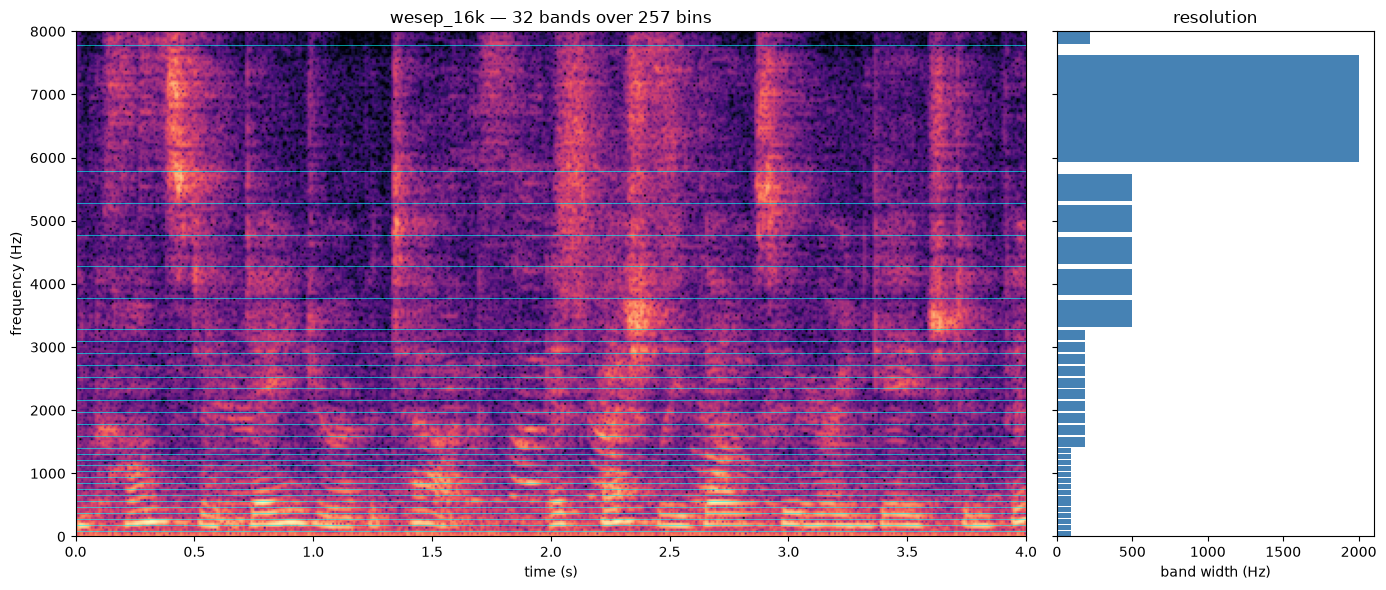

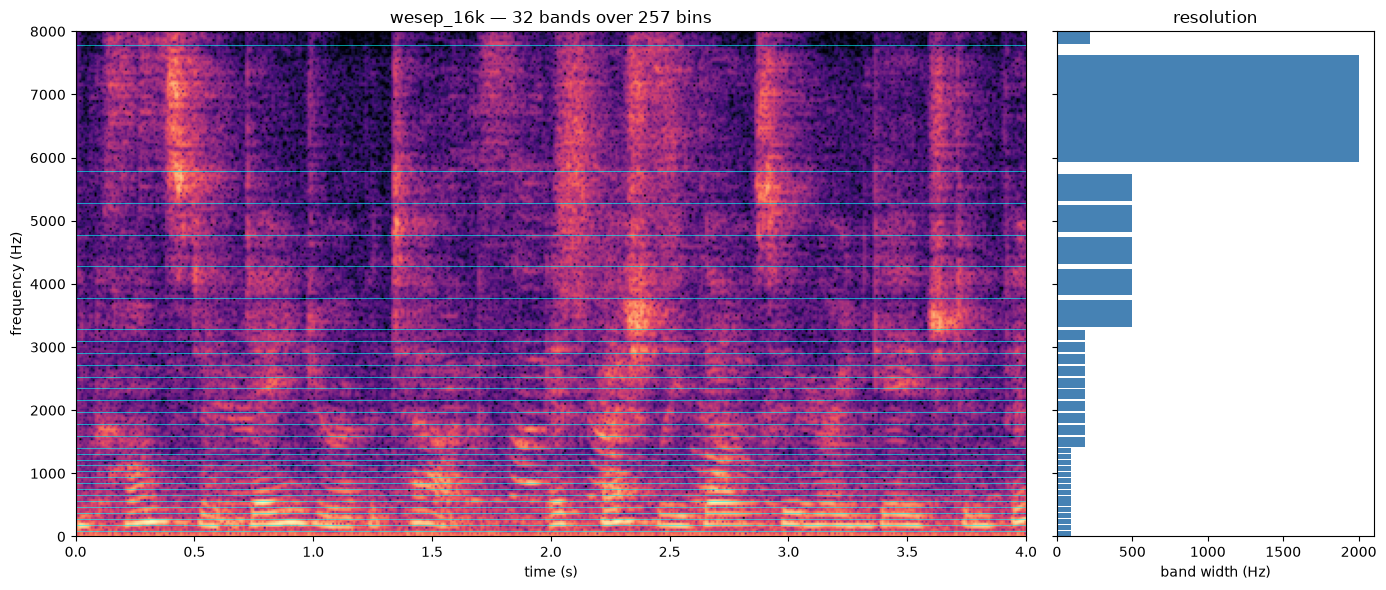

In [55]:
batch = next(iter(smoke_train_loader))
X = stft(batch["mixture"][0:1])[0]
plot_band_plan(X, band_plan(sr, n_fft, "wesep_16k"), sr, n_fft, hop, "wesep_16k")

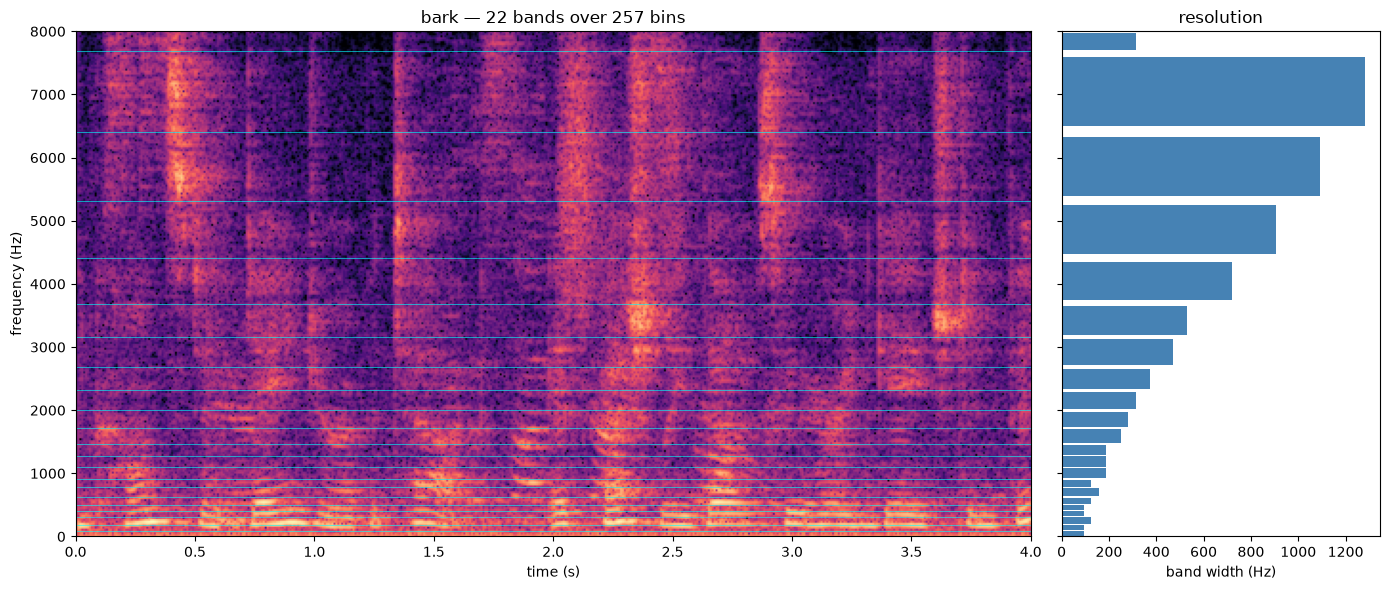

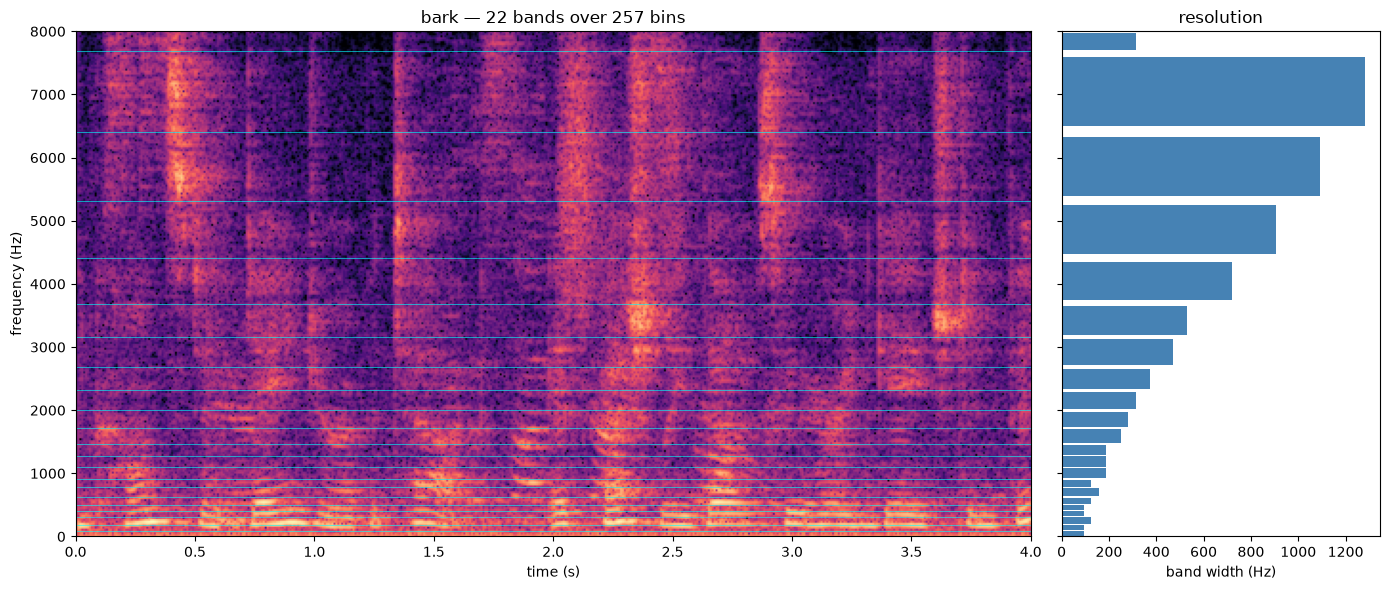

In [56]:
plot_band_plan(X, band_plan(sr, n_fft, "bark"), sr, n_fft, hop, "bark")

## 3. Build the Band Split
Need to slice the (B, C, F, T) into 32 band per band tensors using the widths that I built above. Needs to handle the complex spectrogram which is used for the mask multiply and then the real/imaginary stacked versions.
RMB:
- `B`: Batch-> How many clips we process at once which currently is set to 12
- `C`: Channels -> The feature axis which is set to 2. Will be 3 when we have TF-Map
- `F`: Frequency bins -> 257, the number of bins produced by the STFT
- `T`: Time frames -> 503 calculated using the 4s chunks

Why you split the same spectrogram twice

  This is the part that looks redundant and isn't. Your STFT produces one complex tensor (B, F, T). You need it in two forms:

  (B, 257, T) complex        → split → 32 bands → KEPT ASIDE
                                                  for the mask multiply at the end
                                                 
  (B, 2, 257, T) real/imag   → split → 32 bands → FED TO THE NETWORK
                                                  (SubbandNorm projects each to 128)


Note that due to the different widths we cannot stack these tensors yet. That is what the  SubbandNorm layer will do to project every band to a shared dimensionality. The SubbandNorm layer will be used in the model to project every band to a shared dimensionality, allowing for stacking and further processing.

In [58]:
class BandSplit(nn.Module):
    """ 
    Slice and dice a spectrogram along frequency into per band tensors. 
    
    I will be following the code from  Luo & Yu, "Music Source Separation with Band-Split RNN", TASLP 2023.
    """

    def __init__(self, band_widths):
        super().__init__()
        self.band_widths = list(band_widths) # remember that we have many bands, and each band has a different width in terms of the number of frequency bins.
        self.offsets = np.cumsum([0] + self.band_widths).tolist() # offsets for each band, to slice the spectrogram into bands

    
    def forward(self, spec):
        """
        (B, F, T) complex    -> list of (B, BW, T) complex
        (B, C, F, T) real    -> list of (B, C, BW, T) real
        """
        assert spec.dim() in (3, 4), f"expected 3D or 4D, got {spec.dim()}D"
        assert spec.shape[-2] == self.offsets[-1],  f"{spec.shape[-2]} bins but band plan covers {self.offsets[-1]}"
        return [spec.narrow(-2, lo, w) for lo, w in zip(self.offsets[:-1], self.band_widths)]


In [ ]:
widths = band_plan(sr, n_fft, "wesep_16k")
bs = BandSplit(widths)

X = torch.randn(12, 257, 503, dtype=torch.complex64)      
bands = bs(X)
assert len(bands) == len(widths) == 32
assert [b.shape[-2] for b in bands] == widths
assert torch.equal(torch.cat(bands, dim=-2), X)           

Xri = torch.randn(12, 2, 257, 503)                        
assert torch.equal(torch.cat(bs(Xri), dim=-2), Xri)

try:                                                      
    bs(torch.randn(12, 2, 513, 503))
except AssertionError as e:
    
    print("guard OK:", e)


guard OK: 513 bins but band plan covers 257


## 4. Per-Band Normalization
This module is used to project every band to a shared dimensionality, allowing for stacking and further processing. Each band needs to receive its own normalisation and its own FC. 

In [ ]:
class ChannelWiseLayerNorm(nn.Module):
    """LayerNorm over the channel axis at each time step.
    
    Causal and STATELESS: frame t is normalised using only its own channels, so nothing carries between frames and a 4 s training chunk normalises identically to a 60 s deployed stream.

    NAMING: wesep calls this "cLN", but Conv-TasNet's cLN (Luo & Mesgarani, 2019) means *cumulative* layer norm. Different thing. Cite as channel-wise.
    """
    def __init__(self, num_channels, eps=1e-5):
        super().__init__()
        self.norm = nn.LayerNorm(num_channels, eps=eps)
        
    def forward(self, x):                        # (B, C, T)
        return self.norm(x.transpose(1, -1)).transpose(1, -1)

class SubbandNorm(nn.Module):
    """Per-band normalisation + projection to a common feature dim.

    Yu et al., Interspeech 2023: band-specific fully-connected layers convert each variable-width band into a fixed N-dimensional subband feature, N=128 for their 16 kHz model. Band splitting from Luo & Yu, TASLP 2023.

    This is where the architecture earns its keep. Speech energy falls ~6 dB per octave, so normalising all 257 bins together would leave the high bands numerically invisible. Each band gets its OWN normalisation and its own projection, so a quiet 6 kHz band reaches the RNN with the same representational budget as a loud 200 Hz one.
    """
    def __init__(self, band_widths, in_channels, feature_dim, causal=True):
        super().__init__()
        self.band_widths, self.feature_dim = list(band_widths), feature_dim
        self.blocks = nn.ModuleList()
        for bw in self.band_widths:
            d = bw * in_channels
            norm = ChannelWiseLayerNorm(d) if causal else nn.GroupNorm(1, d)
            self.blocks.append(nn.Sequential(norm, nn.Conv1d(d, feature_dim, 1)))
        
    def forward(self, bands):
        """list of K x (B, C, BW, T) -> (B, K, N, T)"""
        out = []
        for blk, band in zip(self.blocks, bands):
            B, C, BW, T = band.shape
            # reshape, NOT view: BandSplit uses narrow(), which is non-contiguous
            out.append(blk(band.reshape(B, C * BW, T)))
        return torch.stack(out, dim=1)
